In [12]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

In [14]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

learning_rate = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
num_episodes = 20000

In [15]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))


# -------------------------------------------------
# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    return int(np.argmax(Q[state]))

In [16]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

episode_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0
    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = choose_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-learning update:
        # Q(s,a) <- Q(s,a) + alpha * [r + gamma*max Q(s',a') - Q(s,a)]
        if terminated:
            target = reward
        else:
            target = reward + gamma * np.max(Q[next_state])

        Q[state, action] += learning_rate * (target - Q[state, action])

        state = next_state
        total_reward += reward

    episode_rewards.append(total_reward)

    # Gradually reduce exploration.
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

# Derive the state-value function and greedy policy from the learned Q-table.
state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

In [17]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)

In [18]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)


average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.17  0.043 0.048 0.025]
 [0.013 0.006 0.004 0.269]
 [0.005 0.003 0.032 0.009]
 [0.001 0.003 0.002 0.009]
 [0.236 0.009 0.007 0.033]
 [0.    0.    0.    0.   ]
 [0.    0.    0.022 0.   ]
 [0.    0.    0.    0.   ]
 [0.027 0.051 0.039 0.383]
 [0.02  0.705 0.025 0.   ]
 [0.01  0.1   0.    0.023]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.107 0.156 0.847 0.106]
 [0.236 0.976 0.206 0.267]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.17  0.269 0.032 0.009]
 [0.236 0.    0.022 0.   ]
 [0.383 0.705 0.1   0.   ]
 [0.    0.847 0.976 0.   ]]

Learned Policy:
[['L' 'U' 'R' 'U']
 ['L' 'L' 'R' 'L']
 ['U' 'D' 'D' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.516


Name: LOKNAATH P
Reg No: 212223240080


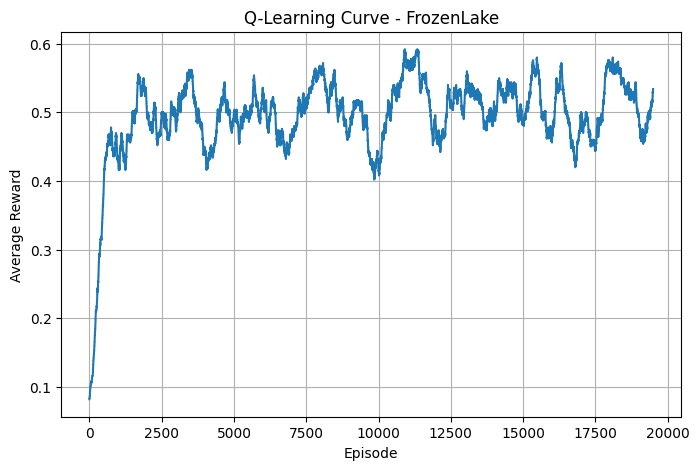

In [19]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------
print("Name: LOKNAATH P")
print("Reg No: 212223240080")
window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)

plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()